In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(158).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(94).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(147).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(99).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(59).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(171).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(71).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(138).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(111).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(197).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(88).JPG
/kaggle/input/d

In [24]:
# Install timm — gives us ViT and many pretrained models in one line
!pip install timm -q

import os, random, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm
from copy import deepcopy
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms, models
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [29]:
# ─── Shared config for all experiments ───────────────────────────────────────
CFG = {
    'data_dir'       : '/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf',
    'save_dir'       : '/kaggle/working/checkpoints/',
    'img_size'       : 224,
    'batch_size'     : 16,
    'num_epochs'     : 30,
    'unfreeze_epoch' : 10,
    'lr'             : 1e-3,
    'fine_tune_lr'   : 1e-5,
    'weight_decay'   : 1e-4,
    'num_classes'    : 3,
    'seed'           : 42,
    # Techniques
    'label_smoothing': 0.1,    # 0 = disabled, 0.1 = recommended
    'mixup_alpha'    : 0.3,    # 0 = disabled, 0.3 = mild mix
    'tta_n'          : 5,      # number of TTA augmentations at test time
}

CLASSES   = ['Healthy', 'Stripe_Rust', 'Septoria']
os.makedirs(CFG['save_dir'], exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG['seed'])
print('Config ready ✅')


Config ready ✅


In [30]:
def get_transforms(img_size, split):
    """
    Train  → aggressive augmentation (small dataset, high overfitting risk)
    Val    → clean resize + normalize only
    TTA    → random augmentation applied at TEST time too (multiple passes)
    """
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    if split == 'train':
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.1),
        ])
    elif split == 'tta':
        # Slightly lighter augmentation for TTA — we want variation but not distortion
        return transforms.Compose([
            transforms.Resize((img_size + 16, img_size + 16)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    else:  # val / test
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])


def get_dataloaders(cfg):
    full_ds = datasets.ImageFolder(root=cfg['data_dir'])
    n, targets = len(full_ds), full_ds.targets

    print(f'Total images : {n}')
    for cls, cnt in zip(full_ds.classes, np.bincount(targets)):
        print(f'  {cls}: {cnt}')

    # Stratified 70 / 15 / 15
    train_idx, temp_idx = train_test_split(
        list(range(n)), test_size=0.30, stratify=targets, random_state=cfg['seed']
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50,
        stratify=[targets[i] for i in temp_idx],
        random_state=cfg['seed']
    )
    print(f'\nSplit — Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

    def make_subset(idx, split):
        ds = datasets.ImageFolder(root=cfg['data_dir'],
                                  transform=get_transforms(cfg['img_size'], split))
        return Subset(ds, idx)

    train_ds = make_subset(train_idx, 'train')
    val_ds   = make_subset(val_idx,   'val')
    test_ds  = make_subset(test_idx,  'test')
    test_ds_tta = make_subset(test_idx, 'tta')  # same test images, with augmentation for TTA

    # Weighted sampler — oversample minority classes
    train_labels = [targets[i] for i in train_idx]
    class_counts = np.bincount(train_labels, minlength=cfg['num_classes'])
    sample_wts   = [1.0 / class_counts[l] for l in train_labels]
    sampler      = WeightedRandomSampler(sample_wts, len(train_idx), replacement=True)

    # Class weights for loss
    cw = 1.0 / (class_counts + 1e-6)
    class_weights = torch.tensor(cw / cw.sum() * cfg['num_classes'], dtype=torch.float32)

    train_loader   = DataLoader(train_ds,     batch_size=cfg['batch_size'], sampler=sampler, num_workers=2, pin_memory=True)
    val_loader     = DataLoader(val_ds,       batch_size=cfg['batch_size'], shuffle=False,   num_workers=2, pin_memory=True)
    test_loader    = DataLoader(test_ds,      batch_size=cfg['batch_size'], shuffle=False,   num_workers=2, pin_memory=True)
    tta_loader     = DataLoader(test_ds_tta,  batch_size=cfg['batch_size'], shuffle=False,   num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, tta_loader, class_weights, test_idx


train_loader, val_loader, test_loader, tta_loader, class_weights, test_idx = get_dataloaders(CFG)

Total images : 407
  Healthy: 102
  septoria: 97
  stripe_rust: 208

Split — Train: 284 | Val: 61 | Test: 62


In [32]:
def mixup_data(x, y, alpha=0.3):
    """
    Mixup: blend two random training images together.
    e.g. 0.7 * Septoria_img + 0.3 * Healthy_img
    The label becomes a soft mix too: [0.3, 0, 0.7] instead of [0, 0, 1]
    This prevents overconfidence and forces smoother decision boundaries.
    alpha controls how aggressive the mixing is. 0.3 = mild, 1.0 = aggressive.
    """
    if alpha <= 0:
        return x, F.one_hot(y, num_classes=CFG['num_classes']).float()

    lam = np.random.beta(alpha, alpha)          # mixing ratio from Beta distribution
    batch_size = x.size(0)
    idx = torch.randperm(batch_size).to(x.device)  # random shuffle of same batch

    mixed_x   = lam * x + (1 - lam) * x[idx]   # blend images
    y_a, y_b  = y, y[idx]

    # Soft labels
    y_one_hot_a = F.one_hot(y_a, CFG['num_classes']).float()
    y_one_hot_b = F.one_hot(y_b, CFG['num_classes']).float()
    mixed_y = lam * y_one_hot_a + (1 - lam) * y_one_hot_b

    return mixed_x, mixed_y


def mixup_criterion(criterion, pred, mixed_y):
    """Loss against soft mixed labels."""
    log_prob = F.log_softmax(pred, dim=1)
    return -(mixed_y * log_prob).sum(dim=1).mean()


print('Mixup defined ✅')

Mixup defined ✅


In [33]:
def build_model(model_name, num_classes, freeze_backbone=True):
    """
    Factory function — returns the right model by name.
    All models use ImageNet pretrained weights.
    All get a custom classifier head for our 3 classes.
    """

    # ── ResNet50 ──────────────────────────────────────────────────────────────
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        in_f = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_f, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        head_params = model.fc.parameters()
        backbone    = model.layer4  # used for unfreezing reference

    # ── EfficientNet-B0 ───────────────────────────────────────────────────────
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        in_f = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(in_f, 256),
            nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, num_classes)
        )
        head_params = model.classifier.parameters()

    # ── EfficientNet-B3 ───────────────────────────────────────────────────────
    elif model_name == 'efficientnet_b3':
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        in_f = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(in_f, 256),
            nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, num_classes)
        )
        head_params = model.classifier.parameters()

    # ── ViT-Base/16 ───────────────────────────────────────────────────────────
    elif model_name == 'vit_base':
        # timm gives us ViT pretrained on ImageNet-21k then finetuned on ImageNet-1k
        model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        in_f = model.num_features
        model.head = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(in_f, 256),
            nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, num_classes)
        )
        head_params = model.head.parameters()

    else:
        raise ValueError(f'Unknown model: {model_name}')

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'[{model_name}] Total: {total:,} | Trainable: {trainable:,}')
    return model


def unfreeze_model(model, model_name):
    """Unfreeze all parameters for fine-tuning phase."""
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  🔓 Backbone unfrozen — trainable params: {trainable:,}')


# Quick sanity check — build each model
print('Building all 4 models...')
for name in ['resnet50', 'efficientnet_b0', 'efficientnet_b3', 'vit_base']:
    m = build_model(name, CFG['num_classes'])
del m
print('\nAll models OK ✅')

Building all 4 models...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 207MB/s] 


[resnet50] Total: 24,033,347 | Trainable: 525,315
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s] 


[efficientnet_b0] Total: 4,336,255 | Trainable: 328,707
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 191MB/s] 


[efficientnet_b3] Total: 11,090,475 | Trainable: 394,243


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

[vit_base] Total: 85,996,291 | Trainable: 197,635

All models OK ✅


In [34]:
def lr_finder(model, train_loader, criterion, start_lr=1e-7, end_lr=1e-1, num_iter=100):
    """
    Smith (2017) LR Range Test.
    Sweeps LR exponentially from start_lr to end_lr over num_iter steps.
    Returns the LR just before loss starts exploding (steepest descent point).
    """
    model_copy  = deepcopy(model).to(device)
    optimizer   = optim.Adam(filter(lambda p: p.requires_grad, model_copy.parameters()), lr=start_lr)
    lr_mult     = (end_lr / start_lr) ** (1 / num_iter)

    lrs, losses = [], []
    best_loss   = float('inf')
    avg_loss    = 0.0
    beta        = 0.98  # smoothing factor

    data_iter = iter(train_loader)

    for i in range(num_iter):
        try:
            imgs, labels = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            imgs, labels = next(data_iter)

        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        out  = model_copy(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        # Smooth the loss
        avg_loss = beta * avg_loss + (1 - beta) * loss.item()
        smooth   = avg_loss / (1 - beta ** (i + 1))

        if smooth < best_loss:
            best_loss = smooth

        # Stop if loss explodes
        if i > 1 and smooth > 4 * best_loss:
            break

        lrs.append(optimizer.param_groups[0]['lr'])
        losses.append(smooth)

        # Increase LR
        for pg in optimizer.param_groups:
            pg['lr'] *= lr_mult

    # Find steepest descent point
    grad = np.gradient(losses)
    best_idx = np.argmin(grad)
    best_lr  = lrs[best_idx] / 10  # take one order of magnitude below steepest drop

    # Plot
    plt.figure(figsize=(8, 4))
    plt.semilogx(lrs, losses)
    plt.axvline(best_lr, color='red', linestyle='--', label=f'Suggested LR: {best_lr:.2e}')
    plt.xlabel('Learning Rate (log scale)')
    plt.ylabel('Smoothed Loss')
    plt.title('LR Finder')
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/lr_finder.png', dpi=120)
    plt.show()
    plt.close()

    del model_copy
    print(f'Suggested LR: {best_lr:.2e}')
    return best_lr


print('LR Finder defined ✅')

LR Finder defined ✅


In [40]:
def train_one_epoch(model, loader, criterion, optimizer, use_mixup=True):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        if use_mixup:
            imgs, mixed_labels = mixup_data(imgs, labels, CFG['mixup_alpha'])
            optimizer.zero_grad()
            out  = model(imgs)
            loss = mixup_criterion(criterion, out, mixed_labels)
        else:
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent gradient explosion
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        out   = model(imgs)
        loss  = criterion(out, labels)
        probs = F.softmax(out, dim=1)
        preds = out.argmax(1)

        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels, all_probs


@torch.no_grad()
def evaluate_with_tta(model, test_loader, tta_loader, criterion, n_tta=5):
    """
    Test Time Augmentation (TTA):
    1. Get standard prediction (no augmentation)
    2. Get n_tta augmented predictions
    3. Average ALL probabilities together
    This reduces variance and typically adds 1-2% accuracy.
    """
    model.eval()

    # Standard pass
    _, _, _, all_labels, base_probs = evaluate(model, test_loader, criterion)
    avg_probs = np.array(base_probs)

    # n_tta augmented passes
    for _ in range(n_tta):
        batch_probs = []
        for imgs, _ in tta_loader:
            imgs  = imgs.to(device)
            out   = model(imgs)
            probs = F.softmax(out, dim=1).cpu().numpy()
            batch_probs.extend(probs)
        avg_probs += np.array(batch_probs)

    avg_probs /= (n_tta + 1)  # average over all passes
    tta_preds  = avg_probs.argmax(axis=1)

    correct    = (np.array(tta_preds) == np.array(all_labels)).sum()
    tta_acc    = correct / len(all_labels)

    return tta_acc, tta_preds, all_labels


print('Training functions defined ✅')

Training functions defined ✅


In [43]:
# ── Shared helper — run this cell ONCE before training any model ─────────────
import os
all_results      = {}
all_history      = {}
all_preds        = {}
all_labels_store = None

def train_model(model_key, model_label):
    """Train a single model and save results to the shared dicts."""
    global all_labels_store

    print('\n' + '═'*60)
    print(f'  🚀 Training: {model_label}')
    print('═'*60)

    ckpt_path = os.path.join(CFG['save_dir'], f'best_{model_key}.pth')

    # ── If already trained, load from checkpoint and skip training ──
    if os.path.exists(ckpt_path):
        print(f'  ⚡ Checkpoint found! Loading saved model — skipping training.')
        model = build_model(model_key, CFG['num_classes'], freeze_backbone=False).to(device)
        ckpt  = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt['model_state'])
        model.eval()

        criterion = nn.CrossEntropyLoss(
            weight=class_weights.to(device),
            label_smoothing=CFG['label_smoothing']
        )

        # Re-evaluate
        test_loss, test_acc, test_preds, test_labels, _ = evaluate(model, test_loader, criterion)
        print(f'  Running TTA...')
        tta_acc, tta_preds, _ = evaluate_with_tta(model, test_loader, tta_loader, criterion, CFG['tta_n'])
        f1     = f1_score(test_labels, test_preds, average='macro')
        f1_tta = f1_score(test_labels, tta_preds,  average='macro')

        all_results[model_label] = {
            'test_acc': test_acc, 'tta_acc': tta_acc,
            'f1': f1, 'f1_tta': f1_tta,
            'best_val_acc': ckpt['val_acc'], 'best_epoch': ckpt['epoch'],
        }
        all_preds[model_label]   = {'preds': test_preds, 'tta_preds': tta_preds}
        all_labels_store         = test_labels
        print(f'  ✅ Loaded! Test Acc: {test_acc:.4f} | TTA Acc: {tta_acc:.4f}')
        torch.cuda.empty_cache()
        return

    # ── Fresh training ────────────────────────────────────────────────────────
    set_seed(CFG['seed'])
    model = build_model(model_key, CFG['num_classes'], freeze_backbone=True).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(device),
        label_smoothing=CFG['label_smoothing']
    )

    print(f'\n🔍 Running LR Finder...')
    found_lr = lr_finder(model, train_loader, criterion)
    head_lr  = min(found_lr, CFG['lr'])
    print(f'   Using LR: {head_lr:.2e}')

    head_params = [p for p in model.parameters() if p.requires_grad]
    optimizer   = optim.AdamW(head_params, lr=head_lr, weight_decay=CFG['weight_decay'])
    scheduler   = CosineAnnealingLR(optimizer, T_max=CFG['num_epochs'])

    history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(1, CFG['num_epochs'] + 1):

        if epoch == CFG['unfreeze_epoch']:
            # Unfreeze only the frozen backbone params — not the head (already in optimizer)
            frozen_params = [p for p in model.parameters() if not p.requires_grad]
            for p in frozen_params:
                p.requires_grad = True
            optimizer.add_param_group({'params': frozen_params, 'lr': CFG['fine_tune_lr']})
            scheduler = CosineAnnealingLR(optimizer, T_max=CFG['num_epochs'] - epoch)
            trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f'  🔓 Backbone unfrozen — trainable params: {trainable:,}')

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, use_mixup=True)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        tag = ''
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({'model_state': model.state_dict(), 'val_acc': val_acc, 'epoch': epoch}, ckpt_path)
            tag = ' ✅'

        print(f'  Ep [{epoch:02d}/{CFG["num_epochs"]}] '
              f'TrLoss:{train_loss:.3f} TrAcc:{train_acc:.3f} | '
              f'VaLoss:{val_loss:.3f} VaAcc:{val_acc:.3f}{tag}')

    # ── Evaluate ──
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    print(f'\n  Loaded best checkpoint (epoch {ckpt["epoch"]}, val_acc={ckpt["val_acc"]:.4f})')

    test_loss, test_acc, test_preds, test_labels, _ = evaluate(model, test_loader, criterion)
    print(f'  Running TTA ({CFG["tta_n"]} passes)...')
    tta_acc, tta_preds, _ = evaluate_with_tta(model, test_loader, tta_loader, criterion, CFG['tta_n'])

    f1     = f1_score(test_labels, test_preds, average='macro')
    f1_tta = f1_score(test_labels, tta_preds,  average='macro')

    all_results[model_label] = {
        'test_acc': test_acc, 'tta_acc': tta_acc,
        'f1': f1, 'f1_tta': f1_tta,
        'best_val_acc': best_val_acc, 'best_epoch': ckpt['epoch'],
    }
    all_history[model_label] = history
    all_preds[model_label]   = {'preds': test_preds, 'tta_preds': tta_preds}
    all_labels_store         = test_labels

    print(f'\n  ✅ {model_label} Done!')
    print(f'     Test Acc : {test_acc:.4f}')
    print(f'     TTA Acc  : {tta_acc:.4f}  (+{(tta_acc-test_acc)*100:.2f}%)')
    print(f'     Macro F1 : {f1:.4f}')
    torch.cuda.empty_cache()

print('Helper function ready ✅  Now run each model cell below.')

Helper function ready ✅  Now run each model cell below.


In [44]:
train_model('resnet50', 'ResNet50')


════════════════════════════════════════════════════════════
  🚀 Training: ResNet50
════════════════════════════════════════════════════════════
  ⚡ Checkpoint found! Loading saved model — skipping training.
[resnet50] Total: 24,033,347 | Trainable: 24,033,347


  Eval :   0%|          | 0/4 [00:00<?, ?it/s]

  Running TTA...


  Eval :   0%|          | 0/4 [00:00<?, ?it/s]

  ✅ Loaded! Test Acc: 0.9355 | TTA Acc: 0.9355


In [45]:
train_model('efficientnet_b3', 'EfficientNet-B3')


════════════════════════════════════════════════════════════
  🚀 Training: EfficientNet-B3
════════════════════════════════════════════════════════════
  ⚡ Checkpoint found! Loading saved model — skipping training.
[efficientnet_b3] Total: 11,090,475 | Trainable: 11,090,475


  Eval :   0%|          | 0/4 [00:00<?, ?it/s]

  Running TTA...


  Eval :   0%|          | 0/4 [00:00<?, ?it/s]

  ✅ Loaded! Test Acc: 0.8548 | TTA Acc: 0.9516


In [46]:
train_model('vit_base', 'ViT-Base')


════════════════════════════════════════════════════════════
  🚀 Training: ViT-Base
════════════════════════════════════════════════════════════
  ⚡ Checkpoint found! Loading saved model — skipping training.
[vit_base] Total: 85,996,291 | Trainable: 85,996,291


  Eval :   0%|          | 0/4 [00:00<?, ?it/s]

  Running TTA...


  Eval :   0%|          | 0/4 [00:00<?, ?it/s]

  ✅ Loaded! Test Acc: 0.8548 | TTA Acc: 0.8871


In [47]:
train_model('efficientnet_b0', 'EfficientNet-B0')


════════════════════════════════════════════════════════════
  🚀 Training: EfficientNet-B0
════════════════════════════════════════════════════════════
  ⚡ Checkpoint found! Loading saved model — skipping training.
[efficientnet_b0] Total: 4,336,255 | Trainable: 4,336,255


  Eval :   0%|          | 0/4 [00:00<?, ?it/s]

  Running TTA...


  Eval :   0%|          | 0/4 [00:00<?, ?it/s]

  ✅ Loaded! Test Acc: 0.9355 | TTA Acc: 0.9194


In [48]:
# ── Build comparison dataframe ────────────────────────────────────────────────
rows = []
for model_label, res in all_results.items():
    rows.append({
        'Model'          : model_label,
        'Best Val Acc'   : f"{res['best_val_acc']:.4f}",
        'Best Epoch'     : res['best_epoch'],
        'Test Acc'       : f"{res['test_acc']:.4f}",
        'TTA Acc'        : f"{res['tta_acc']:.4f}",
        'TTA Gain'       : f"+{(res['tta_acc'] - res['test_acc'])*100:.2f}%",
        'Macro F1'       : f"{res['f1']:.4f}",
        'Macro F1 (TTA)' : f"{res['f1_tta']:.4f}",
    })

df = pd.DataFrame(rows)

# Highlight best model
best_model = max(all_results, key=lambda k: all_results[k]['tta_acc'])
print(f'🏆 Best model: {best_model}')
print(f'   TTA Accuracy: {all_results[best_model]["tta_acc"]:.4f}\n')
print(df.to_string(index=False))

# Save to CSV
df.to_csv('/kaggle/working/model_comparison.csv', index=False)
print('\nSaved to model_comparison.csv')

🏆 Best model: EfficientNet-B3
   TTA Accuracy: 0.9516

          Model Best Val Acc  Best Epoch Test Acc TTA Acc TTA Gain Macro F1 Macro F1 (TTA)
       ResNet50       0.9016          18   0.9355  0.9355   +0.00%   0.9354         0.9375
EfficientNet-B3       0.9344          11   0.8548  0.9516   +9.68%   0.8457         0.9524
       ViT-Base       0.9016          10   0.8548  0.8871   +3.23%   0.8472         0.8842
EfficientNet-B0       0.9508           9   0.9355  0.9194  +-1.61%   0.9338         0.9157

Saved to model_comparison.csv


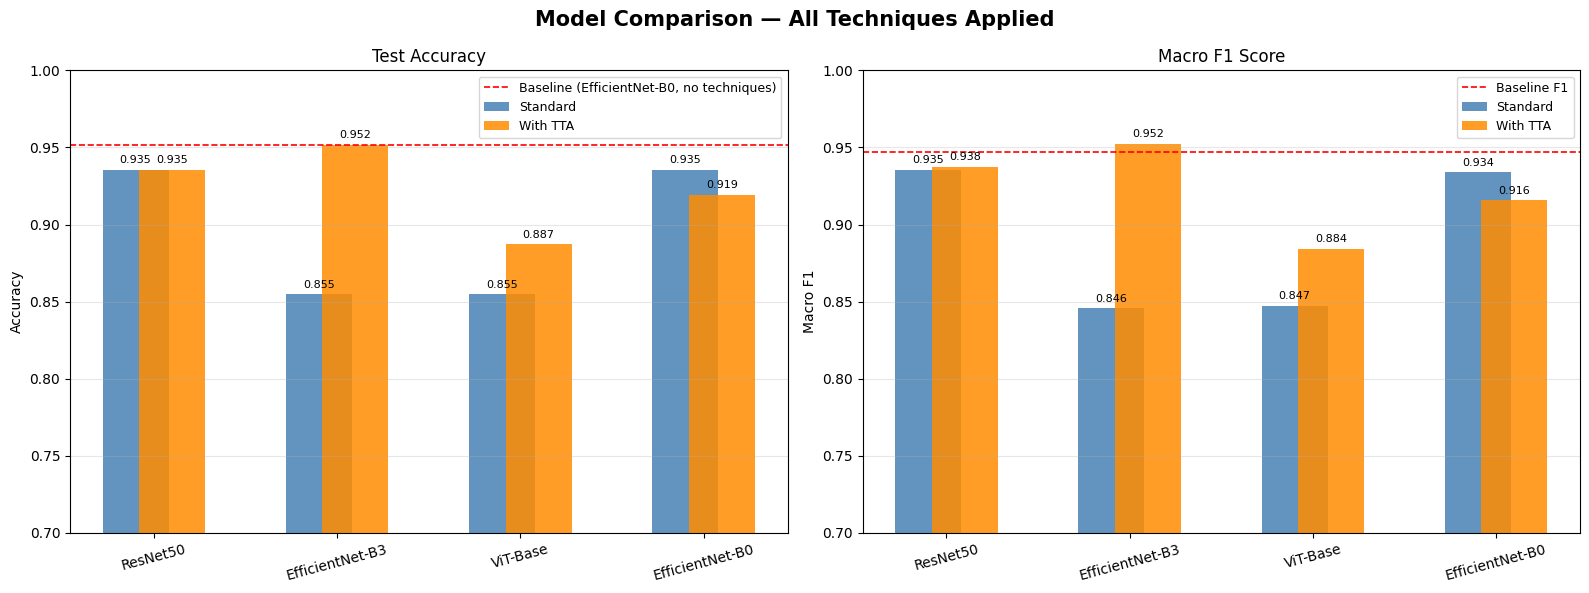

In [49]:
model_labels = list(all_results.keys())
test_accs    = [all_results[m]['test_acc'] for m in model_labels]
tta_accs     = [all_results[m]['tta_acc']  for m in model_labels]
f1_scores    = [all_results[m]['f1']       for m in model_labels]
f1_tta       = [all_results[m]['f1_tta']   for m in model_labels]

x   = np.arange(len(model_labels))
w   = 0.2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison — All Techniques Applied', fontsize=15, fontweight='bold')

# Accuracy
bars1 = axes[0].bar(x - w/2, test_accs, w*1.8, label='Standard', color='steelblue', alpha=0.85)
bars2 = axes[0].bar(x + w/2, tta_accs,  w*1.8, label='With TTA',  color='darkorange', alpha=0.85)
axes[0].axhline(0.9516, color='red', linestyle='--', linewidth=1.2, label='Baseline (EfficientNet-B0, no techniques)')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_labels, rotation=15)
axes[0].set_ylim(0.7, 1.0)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Test Accuracy')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# F1
bars3 = axes[1].bar(x - w/2, f1_scores, w*1.8, label='Standard', color='steelblue', alpha=0.85)
bars4 = axes[1].bar(x + w/2, f1_tta,    w*1.8, label='With TTA',  color='darkorange', alpha=0.85)
axes[1].axhline(0.9469, color='red', linestyle='--', linewidth=1.2, label='Baseline F1')
axes[1].set_xticks(x); axes[1].set_xticklabels(model_labels, rotation=15)
axes[1].set_ylim(0.7, 1.0)
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Macro F1 Score')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison_bar.png', dpi=150)
plt.show()

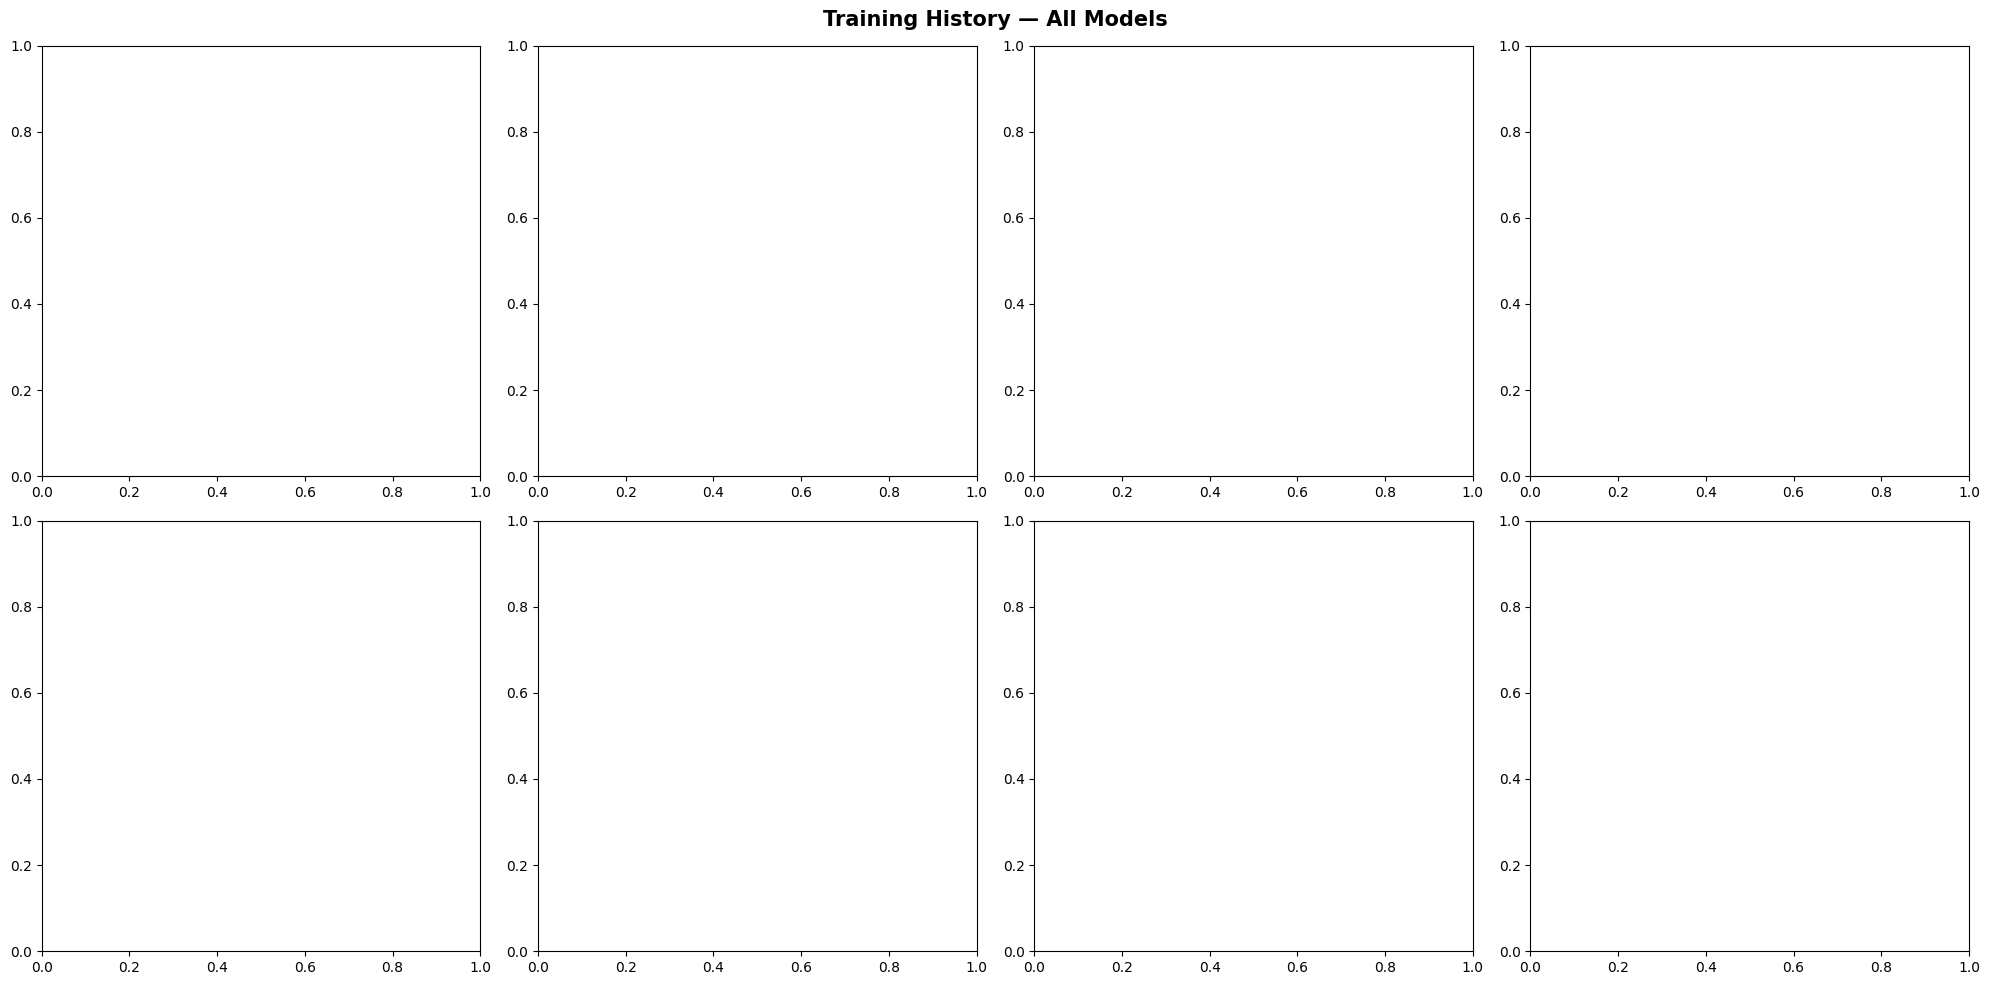

In [50]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Training History — All Models', fontsize=15, fontweight='bold')
colors = ['steelblue', 'darkorange', 'green', 'purple']

for col, (model_label, hist) in enumerate(all_history.items()):
    epochs = range(1, len(hist['train_loss']) + 1)
    c      = colors[col]

    # Loss
    axes[0, col].plot(epochs, hist['train_loss'], label='Train', color=c, alpha=0.8)
    axes[0, col].plot(epochs, hist['val_loss'],   label='Val',   color=c, alpha=0.4, linestyle='--')
    axes[0, col].axvline(CFG['unfreeze_epoch'], color='red', linestyle=':', alpha=0.6)
    axes[0, col].set_title(f'{model_label}\nLoss')
    axes[0, col].legend(fontsize=8); axes[0, col].grid(alpha=0.3)

    # Accuracy
    axes[1, col].plot(epochs, hist['train_acc'], label='Train', color=c, alpha=0.8)
    axes[1, col].plot(epochs, hist['val_acc'],   label='Val',   color=c, alpha=0.4, linestyle='--')
    axes[1, col].axvline(CFG['unfreeze_epoch'], color='red', linestyle=':', alpha=0.6)
    axes[1, col].set_ylim(0, 1)
    axes[1, col].set_title(f'{model_label}\nAccuracy')
    axes[1, col].legend(fontsize=8); axes[1, col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/all_training_curves.png', dpi=150)
plt.show()

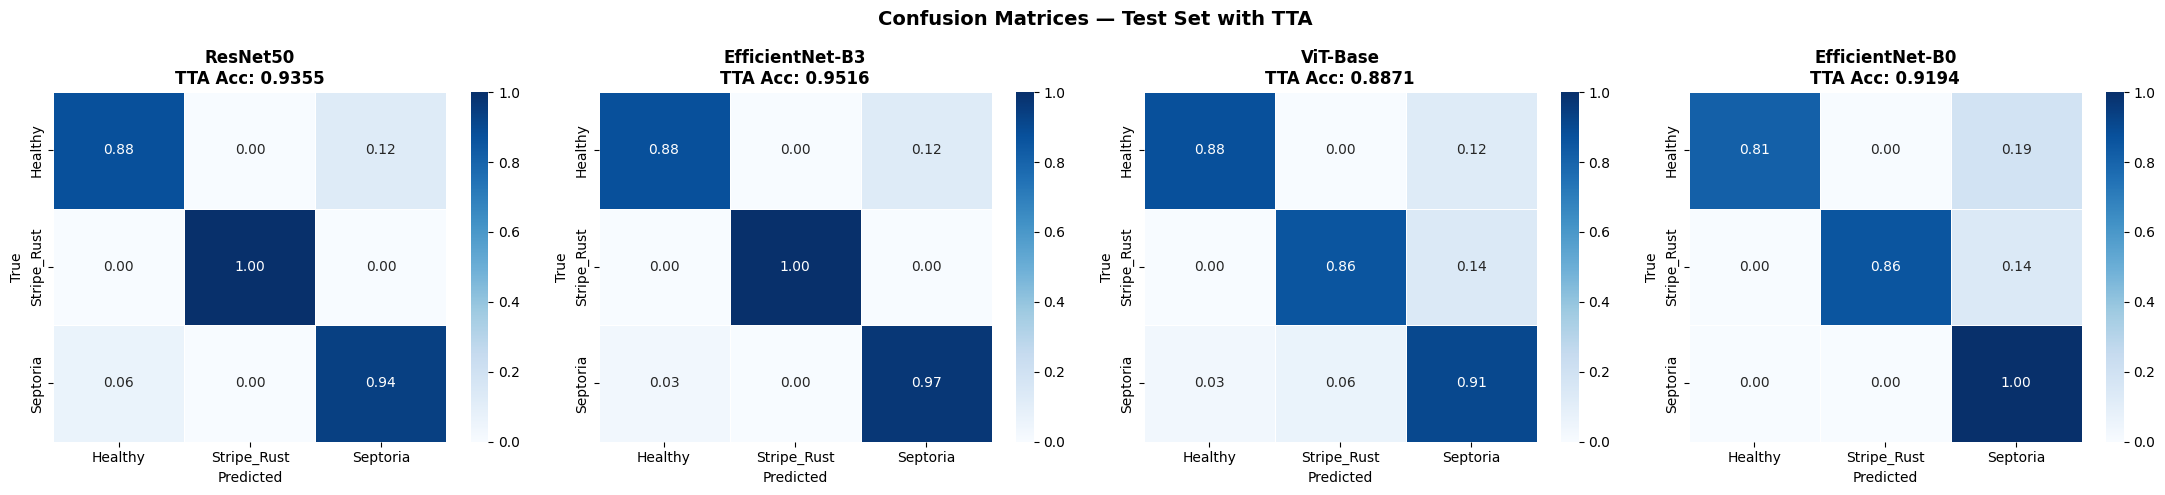

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Confusion Matrices — Test Set with TTA', fontsize=14, fontweight='bold')

for ax, (model_label, preds_dict) in zip(axes, all_preds.items()):
    cm      = confusion_matrix(all_labels_store, preds_dict['tta_preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    acc     = all_results[model_label]['tta_acc']

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=CLASSES, yticklabels=CLASSES,
        linewidths=0.5, ax=ax, vmin=0, vmax=1,
        annot_kws={'size': 10}
    )
    ax.set_title(f'{model_label}\nTTA Acc: {acc:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('/kaggle/working/all_confusion_matrices.png', dpi=150)
plt.show()

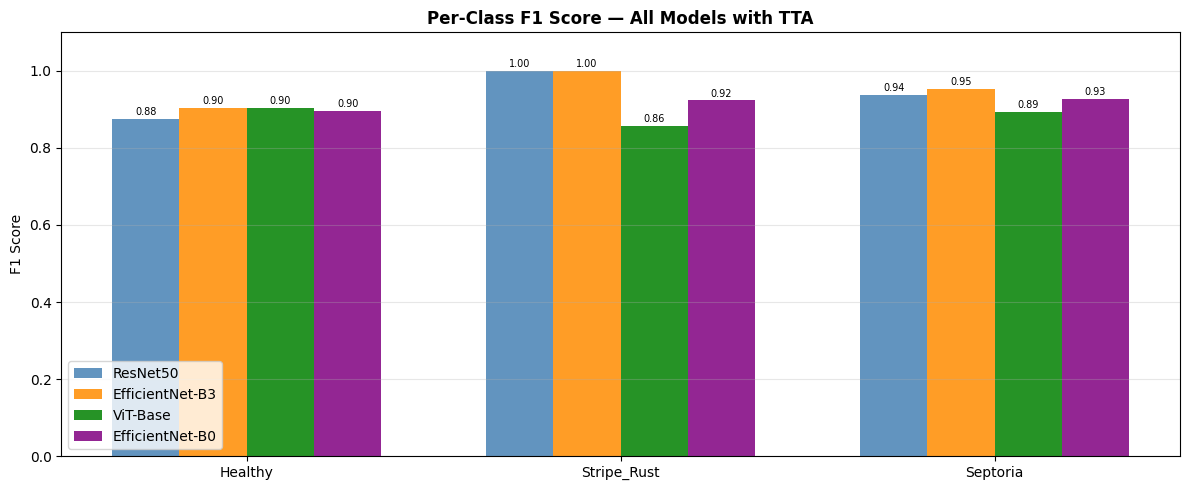

In [52]:
from sklearn.metrics import f1_score as f1_per_class

fig, ax = plt.subplots(figsize=(12, 5))
x   = np.arange(len(CLASSES))
w   = 0.18
colors_models = ['steelblue', 'darkorange', 'green', 'purple']

for i, (model_label, preds_dict) in enumerate(all_preds.items()):
    per_class_f1 = f1_per_class(
        all_labels_store, preds_dict['tta_preds'], average=None, labels=[0, 1, 2]
    )
    offset = (i - 1.5) * w
    bars = ax.bar(x + offset, per_class_f1, w, label=model_label,
                  color=colors_models[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score — All Models with TTA', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/per_class_f1.png', dpi=150)
plt.show()

In [53]:
best_model_label = max(all_results, key=lambda k: all_results[k]['tta_acc'])
best_preds       = all_preds[best_model_label]['tta_preds']

print('═'*60)
print(f'  🏆 Best Model: {best_model_label}')
print(f'  TTA Accuracy : {all_results[best_model_label]["tta_acc"]:.4f}')
print(f'  Macro F1     : {all_results[best_model_label]["f1_tta"]:.4f}')
print('═'*60)
print()
print(classification_report(all_labels_store, best_preds, target_names=CLASSES, digits=4))

════════════════════════════════════════════════════════════
  🏆 Best Model: EfficientNet-B3
  TTA Accuracy : 0.9516
  Macro F1     : 0.9524
════════════════════════════════════════════════════════════

              precision    recall  f1-score   support

     Healthy     0.9333    0.8750    0.9032        16
 Stripe_Rust     1.0000    1.0000    1.0000        14
    Septoria     0.9394    0.9688    0.9538        32

    accuracy                         0.9516        62
   macro avg     0.9576    0.9479    0.9524        62
weighted avg     0.9515    0.9516    0.9512        62



In [57]:
# ── Retrain baseline model quickly for inference ──────────────────────────
import os

ckpt_path = '/kaggle/working/checkpoints/best_model.pth'

if not os.path.exists(ckpt_path):
    print('Checkpoint not found — retraining EfficientNet-B0 baseline...')
    train_model('efficientnet_b0', 'EfficientNet-B0')
    
    # Copy it to the expected path
    import shutil
    src = '/kaggle/working/checkpoints/best_efficientnet_b0.pth'
    shutil.copy(src, ckpt_path)
    print(f'✅ Saved to {ckpt_path}')
else:
    print(f'✅ Checkpoint already exists at {ckpt_path}')

Checkpoint not found — retraining EfficientNet-B0 baseline...

════════════════════════════════════════════════════════════
  🚀 Training: EfficientNet-B0
════════════════════════════════════════════════════════════
  ⚡ Checkpoint found! Loading saved model — skipping training.
[efficientnet_b0] Total: 4,336,255 | Trainable: 4,336,255


  Eval :   0%|          | 0/4 [00:00<?, ?it/s]

  Running TTA...


  Eval :   0%|          | 0/4 [00:00<?, ?it/s]

  ✅ Loaded! Test Acc: 0.9355 | TTA Acc: 0.9194
✅ Saved to /kaggle/working/checkpoints/best_model.pth


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import warnings
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ══════════════════════════════════════════════════════════
#  ✏️  SET YOUR IMAGE PATH HERE (copy from cell above)
# ══════════════════════════════════════════════════════════
IMAGE_PATH = '/kaggle/input/datasets/kritikag20/new-data/img1.jpg'
# ══════════════════════════════════════════════════════════


CLASSES = ['Healthy', 'Stripe_Rust', 'Septoria']
CLASS_INFO = {
    'Healthy'     : ('🟢', 'green',  'No disease detected. The leaf looks healthy.'),
    'Stripe_Rust' : ('🟡', 'gold',   'Stripe Rust — yellow stripes caused by Puccinia striiformis.'),
    'Septoria'    : ('🔴', 'tomato', 'Septoria — brown blotches caused by Zymoseptoria tritici.'),
}


# ── Rebuild model (same architecture as training) ─────────────────────────────
def rebuild_model(checkpoint_path, num_classes=3):
    m = models.efficientnet_b0(weights=None)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(in_f, 256),
        nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, num_classes)
    )
    ckpt = torch.load(checkpoint_path, map_location=device)
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    return m.to(device)


# ── Preprocess ────────────────────────────────────────────────────────────────
def preprocess(img):
    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    return tf(img).unsqueeze(0).to(device)


# ── Run ───────────────────────────────────────────────────────────────────────
print('Loading model...')
inf_model = rebuild_model('/kaggle/working/checkpoints/best_model.pth')

print(f'Loading image: {IMAGE_PATH}')
assert os.path.exists(IMAGE_PATH), f'❌ File not found: {IMAGE_PATH}\nCheck the path printed in the cell above.'
original_img = Image.open(IMAGE_PATH).convert('RGB')
print(f'Image size: {original_img.size}')

tensor     = preprocess(original_img)

with torch.no_grad():
    out   = inf_model(tensor)
    probs = F.softmax(out, dim=1).squeeze().cpu().numpy()

pred_idx   = probs.argmax()
pred_class = CLASSES[pred_idx]
confidence = probs[pred_idx]
emoji, color, description = CLASS_INFO[pred_class]


# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5), facecolor='#f5f5f5')

# Left — image
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(original_img)
ax1.axis('off')
ax1.set_title('Your Image', fontsize=12, pad=10)
rect = patches.FancyBboxPatch(
    (0, 0), 1, 1, transform=ax1.transAxes,
    boxstyle='square,pad=0', linewidth=6,
    edgecolor=color, facecolor='none', clip_on=False
)
ax1.add_patch(rect)

# Right — confidence bars
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_facecolor('#f5f5f5')
bar_colors = [CLASS_INFO[c][1] if c == pred_class else '#d0d0d0' for c in CLASSES]
bars = ax2.barh(np.arange(len(CLASSES)), probs, color=bar_colors, height=0.5,
                edgecolor='white', linewidth=2)
ax2.set_yticks(np.arange(len(CLASSES)))
ax2.set_yticklabels(CLASSES, fontsize=12)
ax2.set_xlim(0, 1.15)
ax2.set_xlabel('Confidence', fontsize=11)
ax2.set_title('Prediction Confidence', fontsize=12, pad=10)
ax2.grid(axis='x', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)
for bar, prob in zip(bars, probs):
    ax2.text(prob + 0.03, bar.get_y() + bar.get_height()/2,
             f'{prob:.1%}', va='center', fontsize=12, fontweight='bold')

plt.suptitle(
    f'{emoji}  Predicted: {pred_class}  —  {confidence:.1%} confident',
    fontsize=14, fontweight='bold', y=1.03, color=color
)
plt.tight_layout()
plt.savefig('/kaggle/working/my_prediction.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Print result ──────────────────────────────────────────────────────────────
print()
print('═' * 52)
print(f'  {emoji}  Predicted  : {pred_class}')
print(f'  Confidence   : {confidence:.2%}')
print(f'  Description  : {description}')
print('─' * 52)
for cls, prob in zip(CLASSES, probs):
    filled = '█' * int(prob * 25)
    empty  = '░' * (25 - int(prob * 25))
    marker = ' ← predicted' if cls == pred_class else ''
    print(f'  {cls:<14} {filled}{empty}  {prob:.2%}{marker}')
print('═' * 52)

Loading model...


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/checkpoints/best_model.pth'